# CA 2: Stock Prices Forecasting

# Part 2:

this part covers advanced data analytics, such as the development and application of SARIMAX (Seasonal AutoRegressive Integrated Moving Average with Exogenous regressors), XGBoost (Extreme Gradient Boosting), LSTM (Long Short-Term Memory), GRU (Gated Recurrent Units), and Facebook Prophet; sentiment analysis by VADER; and the incorporation of an interactive dashboard.

## Libraries

In [246]:
# Data manipulation
import pandas as pd
import numpy as np

#Sentiment Analysis
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

##Plots
import matplotlib.pyplot as plt
import seaborn as sns

#stationarity
from statsmodels.tsa.stattools import adfuller

#Grid Search
import statsmodels.api as sm
#random seachcv
from sklearn.model_selection import RandomizedSearchCV
import random
#Keras tuner
import keras_tuner as kt
#droout
from tensorflow.keras.layers import Dropout

#tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, GRU
#optimizer
from tensorflow.keras.optimizers import Adam

# Accuracy
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

#Scaling
from sklearn.preprocessing import MinMaxScaler

# Models
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from prophet import Prophet

#Dashboard
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.graph_objs as go


# ignore Warnings
import warnings
warnings.filterwarnings("ignore") 

## AMZN Forecast By SARIMAX Model

### Load AMZN Stock prices

In [110]:
# Load stock prices
stock = pd.read_csv('AMZN.csv', parse_dates=['Date'])
stock_amzn = stock[['Date', 'Close']]

In [111]:
stock_amzn.head(5)

,Date,Close
0,2019-12-31,92.391998
1,2020-01-02,94.900497
2,2020-01-03,93.748497
3,2020-01-06,95.143997
4,2020-01-07,95.343002


In [112]:
# Change columns to lowercase
stock_amzn.columns = stock_amzn.columns.str.lower()

In [238]:
stock_amzn.head(5)

,date,close
0,2019-12-31,92.391998
1,2020-01-02,94.900497
2,2020-01-03,93.748497
3,2020-01-06,95.143997
4,2020-01-07,95.343002


### Load AMZN tweets

In [113]:
# load tweets
tweet_amzn = pd.read_csv('amzn_tweet.csv', parse_dates=['date'], dayfirst=True)

In [469]:
tweet_amzn.head(5)

,id,date,ticker,tweet,sentiment
0,100001,2020-01-01,AMZN,$AMZN Dow futures up by 100 points already 🥳,0.3818
1,100022,2020-01-03,AMZN,$AMZN who ever shorted today will be deported ...,0.3612
2,100030,2020-01-06,AMZN,$AMZN I hope we can come close to touching 200...,-0.0516
3,100053,2020-01-07,AMZN,$AMZN CONGRATS TO ALL THE LONG - there were so...,0.7825
4,100096,2020-01-09,AMZN,$AMZN Now it’s moving with the market 😂,0.4404


### Sentiment Analysis on AMZN tweets with SentimentIntensityAnalyzer

In [114]:
# Sentiment Analysis
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if pd.isna(text):
        return 0
    return analyzer.polarity_scores(text)['compound']

tweet_amzn['sentiment'] = tweet_amzn['tweet'].apply(get_sentiment)

In [115]:
#  aggregate sentiment per day
daily_sentiment = tweet_amzn.groupby('date').agg({'sentiment': 'mean'}).reset_index()

In [473]:
daily_sentiment.head(5)

,date,sentiment
0,2020-01-01,0.3818
1,2020-01-03,0.3612
2,2020-01-06,-0.0516
3,2020-01-07,0.7825
4,2020-01-09,0.4404


Some tweets were posted in the same day, the sentiment mean was taken in order to have only one value per day

### Merge AMZN Stock with AMZN tweets

In [71]:
# organize date time starting by day
#stock_amzn['date'] = pd.to_datetime(stock_amzn['date'], dayfirst=True)
#daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'], dayfirst=True)

In [116]:
#Merge stock + sentiment
stock_amzn_s = pd.merge(stock_amzn, daily_sentiment, on='date', how='left')
stock_amzn_s['sentiment'] = stock_amzn_s['sentiment'].fillna(0)  # fill missing sentiment with 0

In [475]:
stock_amzn_s.head(5)

,date,close,sentiment
0,2019-12-31,92.391998,0.0000
1,2020-01-02,94.900497,0.0000
2,2020-01-03,93.748497,0.3612
3,2020-01-06,95.143997,-0.0516
4,2020-01-07,95.343002,0.7825


### Split data 80/20

In [121]:
#Split the data in 80/20

train = stock_amzn_s[stock_amzn_s['date'] < '2020-10-01']
test = stock_amzn_s[stock_amzn_s['date'] >= '2020-10-01']

### Check for Stationarity

In [122]:
# ADF test on your stock data (e.g., 'close')
result = adfuller(train['close'])

# Print results
print('ADF Statistic:', result[0])
print('p-value:', result[1])

# If p-value < 0.05, we reject the null hypothesis and conclude it's stationary

ADF Statistic: -0.6619075904147413
p-value: 0.8563711998390985


The p-value is greater than 0.05, leading to failed to reject the nun hypothesis, the series is non-sationarity

### Appling difference to make the data Stationary

In [123]:
# Appling difference to make the data stationary

# Make a clean copy
train = train.copy()

# Apply differencing
train['close_diff'] = train['close'].diff()

# Drop the first NaN created by differencing
train = train.dropna(subset=['close_diff'])

### Check again for Stationarity

In [124]:
result_diff = adfuller(train['close_diff'].dropna())
print('ADF Statistic (Differenced):', result_diff[0])
print('p-value (Differenced):', result_diff[1])

ADF Statistic (Differenced): -15.621706798653548
p-value (Differenced): 1.7286391919679335e-28


The p-value is below 0.05, the null hypothesis is rejected, the differenced series is stationarity

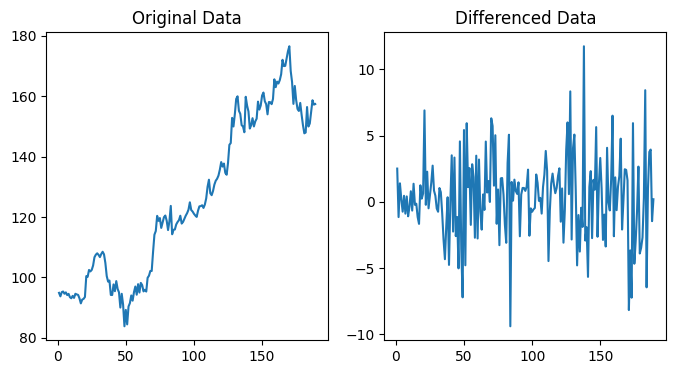

In [125]:
plt.figure(figsize=(8,4))
plt.subplot(1, 2, 1)
plt.plot(train['close'])
plt.title("Original Data")

plt.subplot(1, 2, 2)
plt.plot(train['close_diff'])
plt.title("Differenced Data")
plt.show()

### Building SARIMAX Model

Seasonal AutoRegressive Integrated Moving Average with exogenous variables

AR = Auto-Regressive part (depends on past values)

I = Integrated part (differencing to make data stationary)

MA = Moving Average part (depends on past forecast errors)

S = Seasonal part (optional — for yearly, weekly, monthly patterns)

X = Exogenous variables (in our case: tweet sentiment)

In [126]:
test= test.reset_index()
train= train.reset_index()

In [127]:
#define exogenous variable
exog_vars = ['sentiment']

# Fit the SARIMAX model
model = SARIMAX(train['close_diff'], exog=train[exog_vars], order=(1, 0, 2))  # Notice d=0 because we manually differenced
model_fit = model.fit(disp=False)


In [128]:
# Forecast
forecast_diff = model_fit.predict(start=len(train), end=len(train)+len(test)-1, exog=test[exog_vars])


In [129]:
# recoverind the real price, undo differencing
forecast = forecast_diff.cumsum() + train['close'].iloc[-1]

### Plot Actual vs Forecast

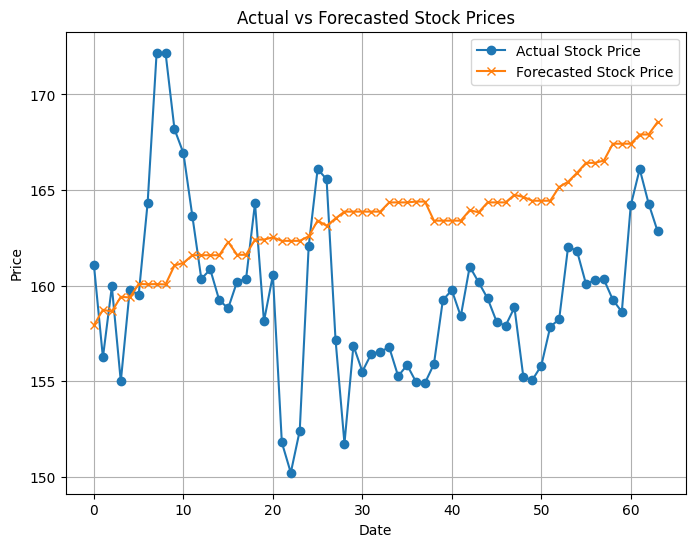

In [130]:
plt.figure(figsize=(8,6))
plt.plot(test.index, test['close'], label='Actual Stock Price', marker='o')
plt.plot(test.index, forecast, label='Forecasted Stock Price', marker='x')
plt.title('Actual vs Forecasted Stock Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

### Check Accuracy (RMSE, MAE and R2)

In [131]:
# Calculate metrics
rmse = np.sqrt(mean_squared_error(test['close'], forecast))
mae = mean_absolute_error(test['close'], forecast)
r2 = r2_score(test['close'], forecast)

# Print them
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² score: {r2:.4f}')

RMSE: 6.4039
MAE: 5.5311
R² score: -1.1586


### Grid search for best parameters

Grid Search is a machine learning technique used to find the best combination of parameters for a model. Grid search systematically tries many combinations and picks the one that gives the best result (lowest AIC, BIC, or validation error).

In [132]:
best_aic = float('inf')
best_order = None
best_model = None

# Grid Search over p and q
for p in range(0, 4):   # Try p = 0 to 3
    for q in range(0, 4):  # Try q = 0 to 3
        try:
            model = sm.tsa.SARIMAX(train['close_diff'], exog=train[['sentiment']], order=(p, 0, q))
            model_fit = model.fit(disp=False)
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_order = (p, q)
                best_model = model_fit
        except:
            continue

print(f"Best SARIMAX order: {best_order} with AIC: {best_aic}")

Best SARIMAX order: (2, 3) with AIC: 965.465358016605


### Training data with best parameters

In [133]:
bp_model = SARIMAX(train['close_diff'], exog=train[['sentiment']], order=(2, 0, 3))
bp_model_fit = bp_model.fit(disp=False)


In [134]:
forecast_diff_bp = bp_model_fit.predict(start=test.index[0], end=test.index[-2], exog=test[['sentiment']])
forecast_bp = forecast_diff_bp.cumsum() + train['close'].iloc[-1]


### Plot Actual VS Forecast with Best parameters

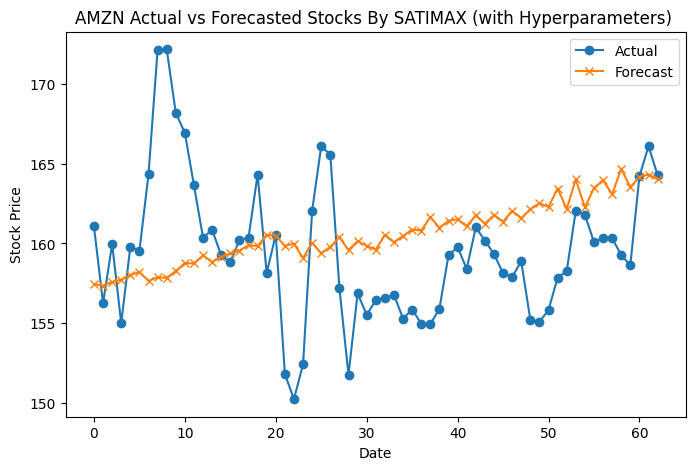

In [135]:
test_trimmed = test.iloc[:len(forecast_bp)]

plt.figure(figsize=(8,5))
plt.plot(test_trimmed.index, test_trimmed['close'], label='Actual', marker='o')
plt.plot(test_trimmed.index, forecast_bp, label='Forecast', marker='x')
plt.title('AMZN Actual vs Forecasted Stocks By SATIMAX (with Hyperparameters) ')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

### Check Accuracy with best parameters

In [136]:
# Calculate metrics
rmse = np.sqrt(mean_squared_error(test_trimmed['close'], forecast_bp))
mae = mean_absolute_error(test_trimmed['close'], forecast_bp)
r2 = r2_score(test_trimmed['close'], forecast_bp)

# Print them
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² score: {r2:.4f}')

RMSE: 5.0901
MAE: 4.0455
R² score: -0.3546


### Forecasting 1, 3 and 7 days ahead 

In [137]:
# put date as datetime and set as index
stock_amzn_s['date'] = pd.to_datetime(stock_amzn_s['date'])
stock_amzn_s.set_index('date', inplace=True)

In [491]:
stock_amzn_s

,close,sentiment
date,,
2019-12-31,92.391998,0.00000
2020-01-02,94.900497,0.00000
2020-01-03,93.748497,0.36120
2020-01-06,95.143997,-0.05160
2020-01-07,95.343002,0.78250
...,...,...
2020-12-24,158.634506,0.00000
2020-12-28,164.197998,0.00000
2020-12-29,166.100006,0.44855


In [138]:
# plit
train = stock_amzn_s.loc[:'2020-12-31']
test = stock_amzn_s.loc['2021-01-01':]

In [139]:
# Forecast horizon
future_days = [1, 3, 7] # days to predict
max_day = max(future_days)

# Create future dates
last_date = train.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=max_day, freq='B')

# Assume future sentiment is same as the last known sentiment
future_sentiment = pd.DataFrame({
    'sentiment': [train['sentiment'].iloc[-1]] * max_day
}, index=future_dates)


In [140]:
# Forecasting differenced values
forecast_diff_future = bp_model_fit.forecast(steps=max_day, exog=future_sentiment)


In [141]:
# Adding last actual close price to reconstruct
last_actual_price = train['close'].iloc[-1]
forecast_price_future = forecast_diff_future.cumsum() + last_actual_price


In [142]:
#forecasting 1,3,7
forecast_1d = forecast_price_future.iloc[0]
forecast_3d = forecast_price_future.iloc[2]
forecast_7d = forecast_price_future.iloc[6]

print("Forecast 1 Day Ahead:", forecast_1d)
print("Forecast 3 Days Ahead:", forecast_3d)
print("Forecast 7 Days Ahead:", forecast_7d)


Forecast 1 Day Ahead: 163.04759770135482
Forecast 3 Days Ahead: 164.20805540777658
Forecast 7 Days Ahead: 165.31715658556308


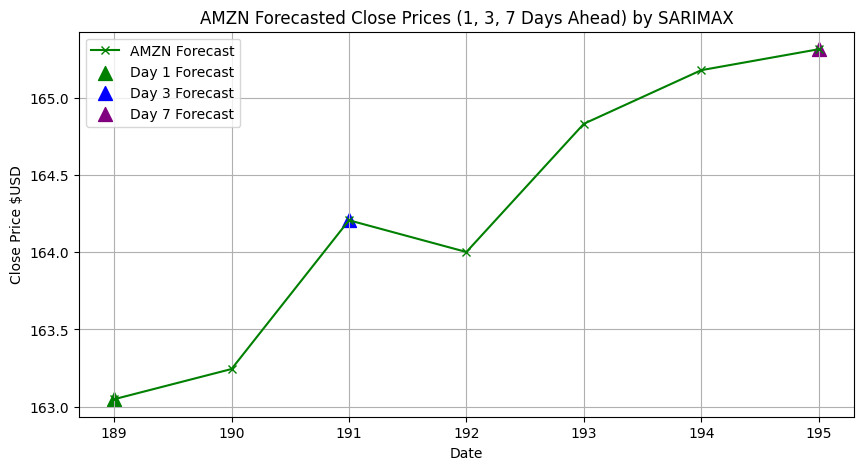

In [143]:
plt.figure(figsize=(10, 5))
plt.plot(forecast_price_future.index, forecast_price_future, marker='x', label='AMZN Forecast', color='green')

# Highlight Day 1, 3, and 7 
plt.scatter(forecast_price_future.index[0], forecast_price_future.iloc[0], color='green', label='Day 1 Forecast', s=100, marker='^')
plt.scatter(forecast_price_future.index[2], forecast_price_future.iloc[2], color='blue', label='Day 3 Forecast', s=100, marker='^')
plt.scatter(forecast_price_future.index[6], forecast_price_future.iloc[6], color='purple', label='Day 7 Forecast', s=100, marker='^')

plt.title('AMZN Forecasted Close Prices (1, 3, 7 Days Ahead) by SARIMAX')
plt.xlabel('Date')
plt.ylabel('Close Price $USD')
plt.legend()
plt.grid(True)
plt.savefig('amzn_forecast.png')
plt.show()

## AAPL Forecast By XGBoost Model

### Load AAPL stock

In [144]:
# Load stock prices
stock = pd.read_csv('AAPL.csv', parse_dates=['Date'])
stock_aapl = stock[['Date', 'Close']]

In [5]:
stock_aapl.head(5)

,Date,Close
0,2019-12-31,73.412498
1,2020-01-02,75.087502
2,2020-01-03,74.357498
3,2020-01-06,74.949997
4,2020-01-07,74.597504


In [145]:
# Change columns to lowercase
stock_aapl.columns = stock_aapl.columns.str.lower()

In [7]:
stock_aapl.head(5)

,date,close
0,2019-12-31,73.412498
1,2020-01-02,75.087502
2,2020-01-03,74.357498
3,2020-01-06,74.949997
4,2020-01-07,74.597504


### Load AAPL tweets

In [264]:
tweet_aapl= pd.read_csv('aapl_tweet.csv', on_bad_lines='skip')


In [265]:
tweet_aapl.head(5)

,id,date,ticker,tweet
0,100003,01/01/2020,AAPL,$AAPL We’ll been riding since last December fr...
1,100007,02/01/2020,AAPL,$AAPL $300 calls First trade of 2020 Congrats ...
2,100008,02/01/2020,AAPL,"$AAPL Remember, if you short every day, one of..."
3,100009,02/01/2020,AAPL,"$AAPL called it, the bear comment below makes ..."
4,100011,02/01/2020,AAPL,Apple is taking things UP in 2020 🚀🚀 $AAPL


In [266]:
tweet_aapl.shape

(1720, 4)

### Sentiment Analysis with SentimentIntensityAnalyzer

In [267]:
# Sentiment Analysis
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if pd.isna(text):
        return 0
    return analyzer.polarity_scores(text)['compound']

tweet_aapl['sentiment'] = tweet_aapl['tweet'].apply(get_sentiment)

In [268]:
#  aggregate sentiment per day
daily_sentiment = tweet_aapl.groupby('date').agg({'sentiment': 'mean'}).reset_index()

In [13]:
tweet_aapl

,id,date,ticker,tweet,sentiment
0,100003,01/01/2020,AAPL,$AAPL We’ll been riding since last December fr...,0.0000
1,100007,02/01/2020,AAPL,$AAPL $300 calls First trade of 2020 Congrats ...,0.7506
2,100008,02/01/2020,AAPL,"$AAPL Remember, if you short every day, one of...",0.0000
3,100009,02/01/2020,AAPL,"$AAPL called it, the bear comment below makes ...",0.4019
4,100011,02/01/2020,AAPL,Apple is taking things UP in 2020 🚀🚀 $AAPL,0.0000
...,...,...,...,...,...
1715,109974,22/12/2020,AAPL,$AAPL Breaking: Apple is working with Tesla to...,0.0000
1716,109976,22/12/2020,AAPL,$AAPL cathie picking up over 400k shares today...,0.2960
1717,109977,22/12/2020,AAPL,$AAPL Ah so the trick to this “investing thing...,-0.3447
1718,109979,22/12/2020,AAPL,"$AAPL holding $125 Jan c, $135 Feb call, $150 ...",0.0000


In [263]:
daily_sentiment.head(5)

,date,polarity_score
0,2020-01-06,0.000000
1,2020-01-10,0.700000
2,2020-01-18,0.000000
3,2020-01-22,0.390152
4,2020-01-23,0.300000


#### Plot Sentiment Distribution by VADER

In [269]:
def categorize_sentiment(value):
    if value > 0.1:
        return "Positive"
    elif value < -0.1:
        return "Negative"
    else:
        return "Neutral"
tweet_aapl["sentiment"] = tweet_aapl["sentiment"].apply(categorize_sentiment)

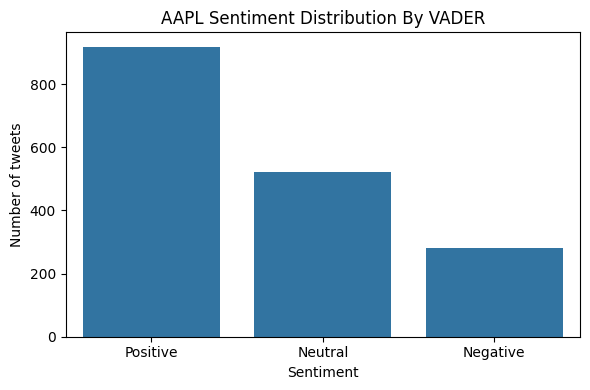

In [270]:
# Count sentiment labels
sentiment_counts = tweet_aapl["sentiment"].value_counts().reset_index()
sentiment_counts.columns = ["Sentiment", "Count"]

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(data=sentiment_counts, x="Sentiment", y="Count")
plt.title("AAPL Sentiment Distribution By VADER")
plt.xlabel("Sentiment")
plt.ylabel("Number of tweets")
plt.tight_layout()
plt.show()

In [271]:
sentiment_counts

,Sentiment,Count
0,Positive,918
1,Neutral,522
2,Negative,280


### Merge AAPL Stock with AAPL tweets

In [272]:
# organize date time starting by day
stock_aapl['date'] = pd.to_datetime(stock_aapl['date'], dayfirst=True)
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'], dayfirst=True)

In [273]:
#Merge stock + sentiment
stock_aapl_s = pd.merge(stock_aapl, daily_sentiment, on='date', how='left')
stock_aapl_s['sentiment'] = stock_aapl_s['sentiment'].fillna(0)  # fill missing sentiment with 0

In [22]:
stock_aapl_s.shape

(254, 3)

### XGBoost Model for Forecasting

Without lagged features, XGBoost cannot understand temporal relationships in the data (i.e., "what happened yesterday" affects "what happens today").
XGBoost requires you to create lags manually.

In [274]:
# Sort by date to avoid any issues
stock_aapl_s = stock_aapl_s.sort_values('date')

stock_aapl_s.head()


,date,close,sentiment
0,2019-12-31,73.412498,0.000000
1,2020-01-02,75.087502,0.465850
2,2020-01-03,74.357498,0.272183
3,2020-01-06,74.949997,0.779300
4,2020-01-07,74.597504,0.541900


In [154]:
stock_aapl_s.shape

(254, 3)

#### Select features and target

In [275]:
# features and target 
FEATURES = ['close', 'sentiment']
TARGET = 'close'

X = stock_aapl_s[FEATURES]
y = stock_aapl_s[TARGET]

#### Split data 80/20

In [276]:
# Train/test split
split = int(len(stock_aapl_s) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]


### XGBoost Model

In [277]:
# XGBoost Model

model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    objective='reg:squarederror',
    random_state=42
)

In [278]:
# fit model
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

### Predict

In [279]:
# Predict
y_pred = model.predict(X_test)

### Plot prediction vs actual

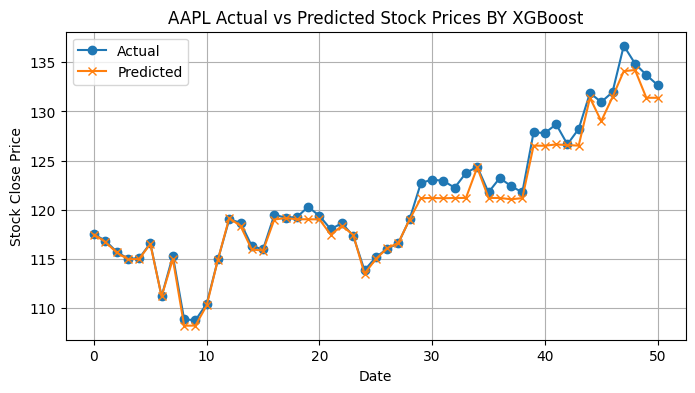

In [280]:
# Plot
y_test = y_test.reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(y_test, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted', marker='x')
plt.title('AAPL Actual vs Predicted Stock Prices BY XGBoost')
plt.xlabel('Date')
plt.ylabel('Stock Close Price')
plt.legend()
plt.grid(True)
plt.show()

### Accuracy

In [281]:
# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print them
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² score: {r2:.4f}')

RMSE: 1.0470
MAE: 0.7197
R² score: 0.9757


### Best Parameters by RandomizedSearchCV

In [282]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

model = XGBRegressor(objective='reg:squarederror', random_state=42)

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("Best params:", random_search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [283]:
xg_best_model = random_search.best_estimator_
xg_best_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [284]:
# Predict
y_pred = xg_best_model.predict(X_test)

In [285]:
# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print them
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² score: {r2:.4f}')

RMSE: 1.0517
MAE: 0.7242
R² score: 0.9755


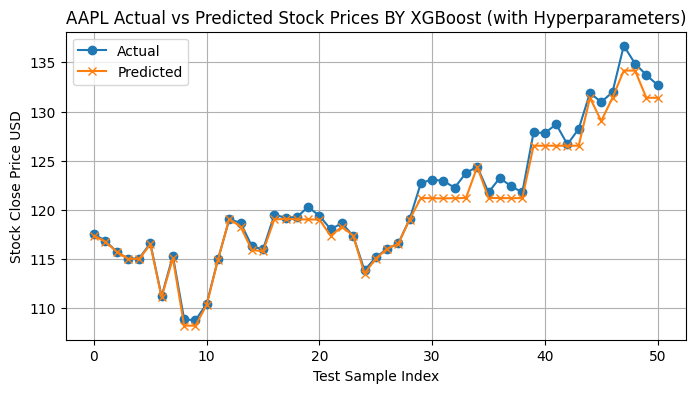

In [286]:
# Plot
y_test = y_test.reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(y_test, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted', marker='x')
plt.title('AAPL Actual vs Predicted Stock Prices BY XGBoost (with Hyperparameters)')
plt.xlabel('Test Sample Index')
plt.ylabel('Stock Close Price USD')
plt.legend()
plt.grid(True)
plt.show()

### Forecasting Day 1, 3 and 7

In [287]:
forecast_days = 7
predictions = []

# Start with the last known data point
last_known = X_test.iloc[-1].copy()

for _ in range(forecast_days):
    # Create new features based on the last known data
    # For example, if using lag features:
    features = {
        'close': last_known['close'],
        'sentiment':last_known['sentiment']
        # Add other necessary features here
    }
    X_new = pd.DataFrame([features])
    
    # Predict the next value
    y_pred =  xg_best_model.predict(X_new)[0]
    predictions.append(y_pred)
    
    # Update 'last_known' for the next iteration
    last_known['close'] = y_pred
    # Update other features in 'last_known' as needed

# Create a DataFrame for the forecasted values
forecast_dates = pd.date_range(start='2021-01-01', periods=forecast_days, freq='D')
future_preds = pd.DataFrame({'date': forecast_dates, 'forecast': predictions})


In [94]:
last_known

close        124.806862
sentiment      0.206167
Name: 253, dtype: float64

In [168]:
future_preds

,date,forecast
0,2021-01-01,131.396164
1,2021-01-02,129.036682
2,2021-01-03,126.519142
3,2021-01-04,125.855919
4,2021-01-05,125.008705
5,2021-01-06,124.823112
6,2021-01-07,124.806862


### Plot days 1, 3 and 7 Forecast

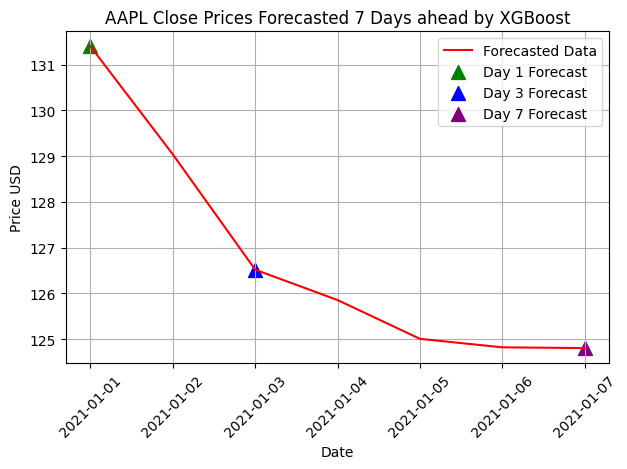

In [288]:
# Plot forecasted data
plt.plot(future_preds['date'], future_preds['forecast'], label='Forecasted Data', color='red')

# Highlight Day 1, 3, and 7 
plt.scatter(future_preds['date'][0], future_preds['forecast'][0], color='green', label='Day 1 Forecast', s=100, marker='^')
plt.scatter(future_preds['date'][2], future_preds['forecast'][2], color='blue', label='Day 3 Forecast', s=100, marker='^')
plt.scatter(future_preds['date'][6], future_preds['forecast'][6], color='purple', label='Day 7 Forecast', s=100, marker='^')

# Customize the plot
plt.xlabel('Date')
plt.ylabel('Price USD')
plt.title('AAPL Close Prices Forecasted 7 Days ahead by XGBoost')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## NFLX Forecast with LSTM Model

### Load NFLX Stock prices

In [170]:
# Load stock prices
stock = pd.read_csv('NFLX.csv', parse_dates=['Date'])
stock_nflx = stock[['Date', 'Close']]

In [283]:
stock_nflx.head(5)

,Date,Close
0,2019-12-31,323.570007
1,2020-01-02,329.809998
2,2020-01-03,325.899994
3,2020-01-06,335.829987
4,2020-01-07,330.750000


In [171]:
# Change columns to lowercase
stock_nflx.columns = stock_nflx.columns.str.lower()

In [172]:
stock_nflx.head(5)

,date,close
0,2019-12-31,323.570007
1,2020-01-02,329.809998
2,2020-01-03,325.899994
3,2020-01-06,335.829987
4,2020-01-07,330.750000


### Load NFLX tweets with TextBlob Sentiment Analysis

In [173]:
# load tweets
tweet_nflx = pd.read_csv('sentiment_nflx.csv', parse_dates=['date'], dayfirst=True)

In [287]:
tweet_nflx.head(5)

,id,date,ticker,tweet,polarity_score
0,100032,2020-01-06,NFLX,$NFLX 🔥🔥🔥✈️ 336 test to possibly test 340s tom...,0.000000
1,100118,2020-01-10,NFLX,$NFLX Morningstar’s fair value estimate is $135 😳,0.700000
2,100237,2020-01-18,NFLX,"$NFLX 💵 booked a week earlier, ER scares me",0.000000
3,100254,2020-01-22,NFLX,$NFLX love when they lie to kill shorts so the...,0.250000
4,100278,2020-01-22,NFLX,"$NFLX sooo if 360 doesn't work, let's live to...",0.170455


In [174]:
#  aggregate sentiment per day
daily_sentiment = tweet_nflx.groupby('date').agg({'polarity_score': 'mean'}).reset_index()

In [175]:
daily_sentiment.head(5)

,date,polarity_score
0,2020-01-06,0.000000
1,2020-01-10,0.700000
2,2020-01-18,0.000000
3,2020-01-22,0.390152
4,2020-01-23,0.300000


Some tweets were posted in the same day, the polarity_score mean was taken in order to have only one value per day

### Merge NFLX Stock with NFLX tweets

In [71]:
# organize date time starting by day
#stock_amzn['date'] = pd.to_datetime(stock_amzn['date'], dayfirst=True)
#daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'], dayfirst=True)

In [176]:
#Merge stock + sentiment
stock_nflx_s = pd.merge(stock_nflx, daily_sentiment, on='date', how='left')
stock_nflx_s['polarity_score'] = stock_nflx_s['polarity_score'].fillna(0)  # fill missing sentiment with 0

In [177]:
stock_nflx_s.head(5)

,date,close,polarity_score
0,2019-12-31,323.570007,0.0
1,2020-01-02,329.809998,0.0
2,2020-01-03,325.899994,0.0
3,2020-01-06,335.829987,0.0
4,2020-01-07,330.750000,0.0


### Scaling the data using MinMaxScaler

In [178]:
#Scale features
scaler = MinMaxScaler()
scaled = scaler.fit_transform(stock_nflx_s[['close', 'polarity_score']])
stock_nflx_s[['close_s', 'sent_s']] = scaled

### sort and reset index

In [179]:
# Sort and reset index
stock_nflx_s = stock_nflx_s.sort_values('date').reset_index(drop=True)
stock_nflx_s

,date,close,polarity_score,close_s,sent_s
0,2019-12-31,323.570007,0.0,0.095961,0.402685
1,2020-01-02,329.809998,0.0,0.120174,0.402685
2,2020-01-03,325.899994,0.0,0.105002,0.402685
3,2020-01-06,335.829987,0.0,0.143533,0.402685
4,2020-01-07,330.750000,0.0,0.123821,0.402685
...,...,...,...,...,...
249,2020-12-24,513.969971,0.0,0.834775,0.402685
250,2020-12-28,519.119995,0.0,0.854759,0.402685
251,2020-12-29,530.869995,0.0,0.900353,0.402685
252,2020-12-30,524.590027,0.0,0.875985,0.402685


In [180]:
# Prepare sequences window 1 means take the whole dataset
WINDOW = 1
X, y, dates = [], [], []
for i in range(WINDOW, len(stock_nflx_s)):
    X.append(scaled[i-WINDOW:i])
    y.append(scaled[i, 0])
    dates.append(stock_nflx_s['date'].iloc[i])

X, y = np.array(X), np.array(y)
dates = pd.Series(dates)


### Split data 80/20

In [181]:
# split train/test (80/20)
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:] #80%
y_train, y_test = y[:split], y[split:] #20%
dates_test = dates.iloc[split:].reset_index(drop=True)

### train model

In [350]:
#model 
model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(WINDOW, 2,)),
    Dense(1)
])
#optimizer
model.compile(optimizer='adam', loss='mean_squared_error')
#fit model
model.fit(X_train, y_train, epochs=100, batch_size=16)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3332
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2605 
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1599 
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1092 
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0755 
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0420 
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0335 
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0348 
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0306 
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0280 
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0253 
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0274 
Epoch 13/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0235 
Epoch 14/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0195 
Epoch 15/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss

the model was trained at 100 epochs, obtaining a loss of 0.0021

### Predict

In [351]:
# predict
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


### Undo scale

In [352]:
inv_pred = scaler.inverse_transform(np.hstack([y_pred, np.zeros_like(y_pred)]))[:,0]
inv_actual = scaler.inverse_transform(np.hstack([y_test.reshape(-1,1), np.zeros_like(y_test.reshape(-1,1))]))[:,0]

### Plot Actual VS Predicted

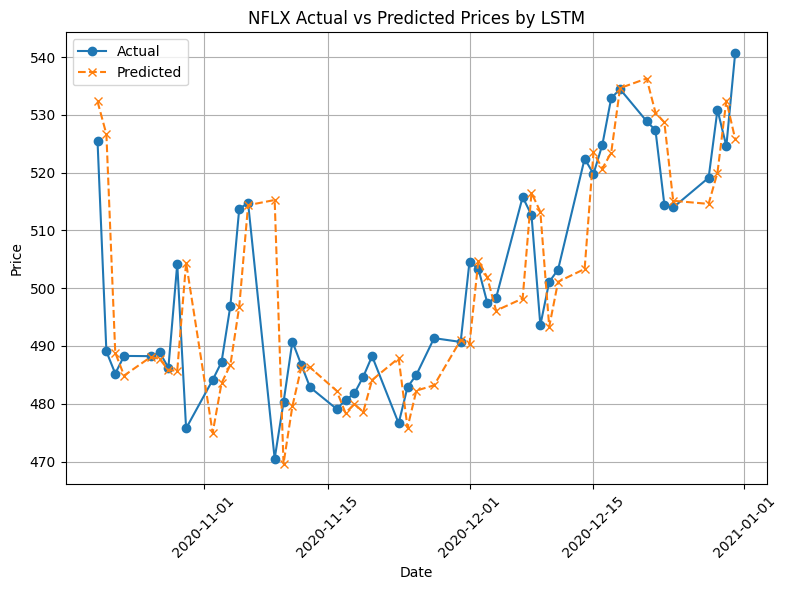

In [353]:
#plot
plt.figure(figsize=(8,6))
plt.plot(dates_test, inv_actual, label='Actual', marker='o')
plt.plot(dates_test, inv_pred, label='Predicted', marker='x', linestyle='--')
plt.title('NFLX Actual vs Predicted Prices by LSTM')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Check Accuracy

In [354]:
# Calculate metrics
rmse = np.sqrt(mean_squared_error(inv_pred, inv_actual))
mae = mean_absolute_error(inv_pred, inv_actual)
r2 = r2_score(inv_pred, inv_actual)

# Print them
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² score: {r2:.4f}')

RMSE: 12.4409
MAE: 8.4658
R² score: 0.5698


### Hyperparameters by Keras Tuner

In [182]:
def build_model(hp):
    model = Sequential()
    
    # Tune number of LSTM units
    model.add(LSTM(
        units=hp.Int('lstm_units', min_value=32, max_value=128, step=32),
        return_sequences=False,
        input_shape=(WINDOW, 2)
    ))
    
    # Optional: Tune Dense layer size or add more layers
    model.add(Dense(1))

    # Tune optimizer learning rate
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
        ),
        loss='mean_squared_error'
    )

    return model


In [183]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=50,
    executions_per_trial=1,
    directory='lstm_tuning',
    project_name='time_series'
)

# Search
tuner.search(X_train, y_train,
             epochs=100,
             batch_size=16,
             validation_split=0.2)

# Retrieve the best model
lstm_best_model = tuner.get_best_models(num_models=1)[0]


Reloading Tuner from lstm_tuning\time_series\tuner0.json



#### Best parameters

In [184]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hp.values)


{'lstm_units': 32, 'learning_rate': 0.008054449226918406}


#### Train the model with best parameters

In [185]:
final_model = tuner.hypermodel.build(best_hp)
final_model.fit(X_train, y_train, epochs=100, batch_size=16)


Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2340
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0412 
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0280 
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0213 
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0128 
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0067 
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0039 
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021  
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028 
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023 
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0025 
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 
Epoch 13/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 
Epoch 14/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0021 
Epoch 15/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - los

loss: 0.0021

In [186]:
# predict
y_pred = final_model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


In [187]:
inv_pred = scaler.inverse_transform(np.hstack([y_pred, np.zeros_like(y_pred)]))[:,0]
inv_actual = scaler.inverse_transform(np.hstack([y_test.reshape(-1,1), np.zeros_like(y_test.reshape(-1,1))]))[:,0]

#### Check Accuracy

In [188]:
# Calculate metrics
rmse = np.sqrt(mean_squared_error(inv_pred, inv_actual))
mae = mean_absolute_error(inv_pred, inv_actual)
r2 = r2_score(inv_pred, inv_actual)

# Print them
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² score: {r2:.4f}')

RMSE: 12.1156
MAE: 7.9772
R² score: 0.5213


#### Plot Actual vs Predicted

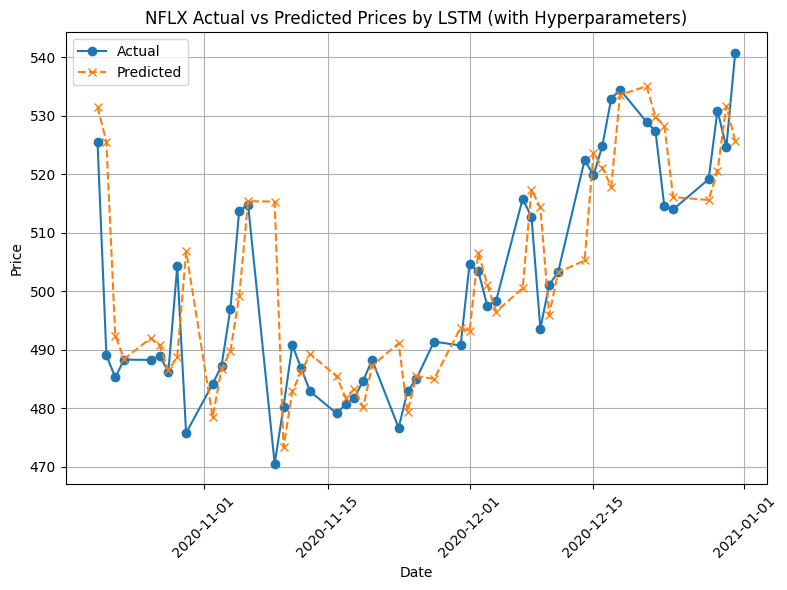

In [189]:
#plot
plt.figure(figsize=(8,6))
plt.plot(dates_test, inv_actual, label='Actual', marker='o')
plt.plot(dates_test, inv_pred, label='Predicted', marker='x', linestyle='--')
plt.title('NFLX Actual vs Predicted Prices by LSTM (with Hyperparameters)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Forecast 1, 3 and 7 days ahead

In [190]:
WINDOW = 1   # same window you used in training
HORIZON = 7   # how many days to forecast


In [191]:
scaled = scaler.transform(stock_nflx_s[['close','polarity_score']])
last_window = scaled[-WINDOW:].copy()

In [192]:
# get the last scaled sentiment value
sent_last = last_window[-1, 1]

In [193]:
#recursively forecast 

preds_scaled = []
current_window = last_window.copy()

for _ in range(HORIZON):
    # a) predict next scaled close
    next_close_scaled = final_model.predict(current_window[np.newaxis, :, :])[0,0]
    
    # b) build next input row = [predicted_close, last_sentiment]
    next_row = np.array([next_close_scaled, sent_last])
    
    # c) slide the window and append
    current_window = np.vstack([ current_window[1:], next_row ])
    
    preds_scaled.append(next_close_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


In [195]:
# invert scaling to get actual price forecasts
preds_price = []
for cs in preds_scaled:
    inv = scaler.inverse_transform([[cs, sent_last]])
    preds_price.append(inv[0,0])

#### Forecasting

In [196]:
#grab the 1-day, 3-day, and 7-day forecasts
forecast_1d = preds_price[0]
forecast_3d = preds_price[2]
forecast_7d = preds_price[6]

In [197]:
print(f"1-day ahead forecast:  ${forecast_1d:.2f}")
print(f"3-day ahead forecast:  ${forecast_3d:.2f}")
print(f"7-day ahead forecast:  ${forecast_7d:.2f}")

1-day ahead forecast:  $540.91
3-day ahead forecast:  $541.25
7-day ahead forecast:  $541.80


#### Plot 7 days Forecast

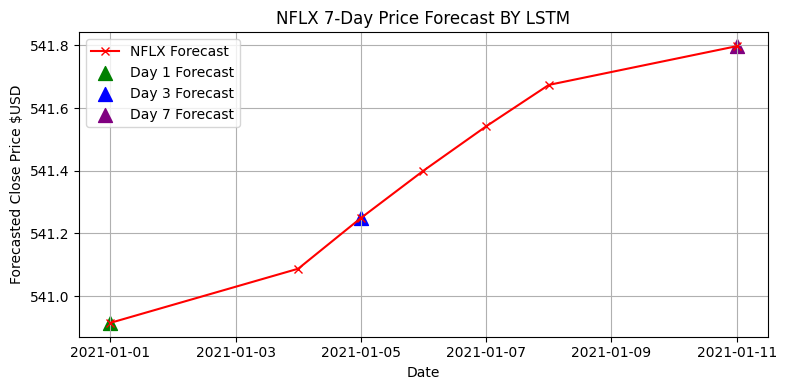

In [198]:
# Plot the 7-day forecast 
last_date = pd.to_datetime(stock_nflx_s['date'].iloc[-1])
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=HORIZON)

plt.figure(figsize=(8,4))
plt.plot(future_dates, preds_price, marker='x', label='NFLX Forecast',color='red')

# Highlight Day 1, 3, and 7 
plt.scatter(future_dates[0], preds_price[0], color='green', label='Day 1 Forecast', s=100, marker='^')
plt.scatter(future_dates[2], preds_price[2], color='blue', label='Day 3 Forecast', s=100, marker='^')
plt.scatter(future_dates[6], preds_price[6], color='purple', label='Day 7 Forecast', s=100, marker='^')

plt.title("NFLX 7-Day Price Forecast BY LSTM")
plt.xlabel("Date")
plt.ylabel("Forecasted Close Price $USD")
plt.grid(True)
plt.legend()
plt.tight_layout()


plt.savefig("nflx_forecast.png")
plt.show()

## NVDA Forecast By GRU Model

### Load NVDA Stock prices

In [199]:
# Load stock prices
stock = pd.read_csv('NVDA.csv', parse_dates=['Date'])
stock_nvda = stock[['Date', 'Close']]

In [398]:
stock_nvda.head(5)

,Date,Close
0,2019-12-31,58.825001
1,2020-01-02,59.977501
2,2020-01-03,59.017502
3,2020-01-06,59.264999
4,2020-01-07,59.982498


In [200]:
# Change columns to lowercase
stock_nvda.columns = stock_nvda.columns.str.lower()

In [201]:
stock_nvda.head(5)

,date,close
0,2019-12-31,58.825001
1,2020-01-02,59.977501
2,2020-01-03,59.017502
3,2020-01-06,59.264999
4,2020-01-07,59.982498


### Load NVDA tweets with TextBlob Sentiment Analysis

In [202]:
# load tweets
tweet_nvda = pd.read_csv('sentimental_nvda.csv', parse_dates=['date'], dayfirst=True)

In [203]:
tweet_nvda.head(5)

,id,date,ticker,tweet,polarity_score
0,100014,2020-01-03,NVDA,$NVDA This should be at least 300 already 🤔💹💸💸,-0.300000
1,100109,2020-01-10,NVDA,$NVDA i love when I’m right 🙏🏼 💰💰💰💰💰💰💰💰,0.392857
2,100678,2020-02-11,NVDA,"$NVDA thoughts opinions, avg down? Sell tomorr...",0.022222
3,100746,2020-02-13,NVDA,$NVDA Easy money don’t miss these alerts🤑✅,0.433333
4,100809,2020-02-19,NVDA,$NVDA 👏👏💸💸💸👏👏,0.000000


In [204]:
#  aggregate sentiment per day
daily_sentiment_nvda = tweet_nvda.groupby('date').agg({'polarity_score': 'mean'}).reset_index()

In [205]:
daily_sentiment_nvda.head(5)

,date,polarity_score
0,2020-01-03,-0.300000
1,2020-01-07,0.800000
2,2020-01-10,0.392857
3,2020-02-10,0.650000
4,2020-02-11,0.022222


### Merge NVDA Stock with NVDA tweets

In [71]:
# organize date time starting by day
#stock_amzn['date'] = pd.to_datetime(stock_amzn['date'], dayfirst=True)
#daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'], dayfirst=True)

In [206]:
#Merge stock + sentiment
stock_nvda_s = pd.merge(stock_nvda, daily_sentiment_nvda, on='date', how='left')
stock_nvda_s['polarity_score'] = stock_nvda_s['polarity_score'].fillna(0)  # fill missing sentiment with 0

In [207]:
stock_nvda_s.head(5)

,date,close,polarity_score
0,2019-12-31,58.825001,0.0
1,2020-01-02,59.977501,0.0
2,2020-01-03,59.017502,-0.3
3,2020-01-06,59.264999,0.0
4,2020-01-07,59.982498,0.8


### Feature Scaling

In [208]:
# Feature scaling
scaler = MinMaxScaler()
scaled = scaler.fit_transform(stock_nvda_s[['close', 'polarity_score']])



### Selection features X and Y

In [209]:
# Parameters
window_size = 1  # Number of past days to look at

# Prepare sequences
def create_sequences(data, window_size):
    X = []
    y = []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i, 0])  # close price is at index 0
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, window_size)


In [421]:
X.shape

(253, 1, 2)

### Split data 80/20

In [210]:
# 1. Split your sequences into train and test
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

### Gated Recurrent Unit (GRU) Model 

A Gated Recurrent Unit (GRU) is a type of Recurrent Neural Network (RNN) architecture designed to handle sequential data, like time series, text, or audio.

It was introduced by Cho et al. (2014) as a simpler alternative to the more complex Long Short-Term Memory (LSTM) unit.

In [211]:
# Build model
model = Sequential()
model.add(GRU(50, activation='tanh', recurrent_activation='sigmoid', return_sequences=False, input_shape=(X.shape[1], X.shape[2])))
model.add(Dense(1))  # Predict close price

#optimizer
model.compile(optimizer='adam', loss='mse')


### Train model

In [426]:
# Train
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2884
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2094 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1611 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1014 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0750 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0649 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0554 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0486 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0489 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0455 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0403 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0437 
Epoch 13/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0381 
Epoch 14/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0350 
Epoch 15/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0346 
Epoch 16/100
7/7 ━━━

loss: 9.1314e-04

### Predict

In [427]:
#Predict on X_test
y_pred_scaled = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


### Undo scaling

In [428]:
# Invert scaling 
y_pred_full = np.hstack([y_pred_scaled, np.zeros_like(y_pred_scaled)])
y_test_full = np.hstack([y_test.reshape(-1,1), np.zeros_like(y_test.reshape(-1,1))])

y_pred = scaler.inverse_transform(y_pred_full)[:,0]
y_true = scaler.inverse_transform(y_test_full)[:,0]

### Plot NVDA Predicted vs Actual

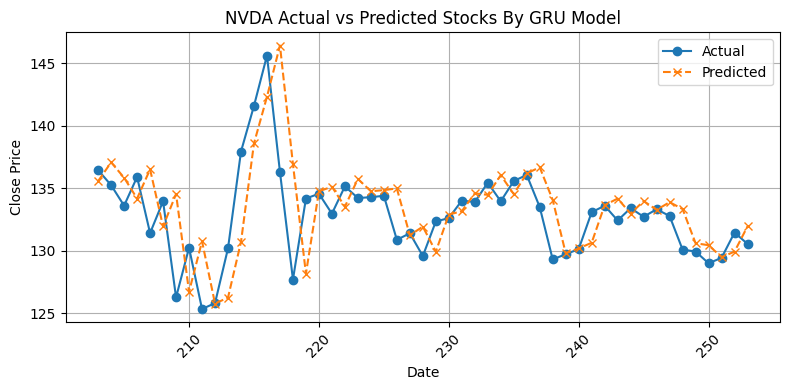

In [429]:
# Recover test dates
dates = stock_nvda_s.index[window_size:][split_idx:]  # align dates to X_test

plt.figure(figsize=(8,4))
plt.plot(dates, y_true, label='Actual', marker='o')
plt.plot(dates, y_pred, label='Predicted', marker='x', linestyle='--')
plt.title('NVDA Actual vs Predicted Stocks By GRU Model')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Accuracy

In [430]:
# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

# Print them
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² score: {r2:.4f}')

RMSE: 3.3497
MAE: 2.3317
R² score: 0.1087


### Hyperparameters by Keras Tuner

Defining the Model and Hyperparameters

In [212]:
def build_model(hp):
    model = Sequential()
    model.add(GRU(
        units=hp.Int('units', min_value=32, max_value=128, step=32),
        activation='tanh',
        return_sequences=False,
        input_shape=(X.shape[1], X.shape[2])
    ))
    
    model.add(Dropout(hp.Float('dropout', 0.0, 0.5, step=0.1)))
    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')),
        loss='mse'
    )
    
    return model


Random Search

In [213]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='gru_tuning',
    project_name='gru_model'
)

tuner.search(
    X_train, y_train,
    epochs=100,
    validation_split=0.2 
)
best_model = tuner.get_best_models(1)[0]


Reloading Tuner from gru_tuning\gru_model\tuner0.json


In [14]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hp.values)


{'units': 128, 'dropout': 0.2, 'learning_rate': 0.008628568315358838}


In [214]:
best_model = tuner.get_best_models(1)[0]


In [215]:
#Predict on X_test
y_pred_scaled = best_model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


In [216]:
# Invert scaling 
y_pred_full = np.hstack([y_pred_scaled, np.zeros_like(y_pred_scaled)])
y_test_full = np.hstack([y_test.reshape(-1,1), np.zeros_like(y_test.reshape(-1,1))])

y_pred = scaler.inverse_transform(y_pred_full)[:,0]
y_true = scaler.inverse_transform(y_test_full)[:,0]

#### Accuracy

In [217]:
# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

# Print them
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² score: {r2:.4f}')

RMSE: 3.2334
MAE: 2.3089
R² score: 0.1696


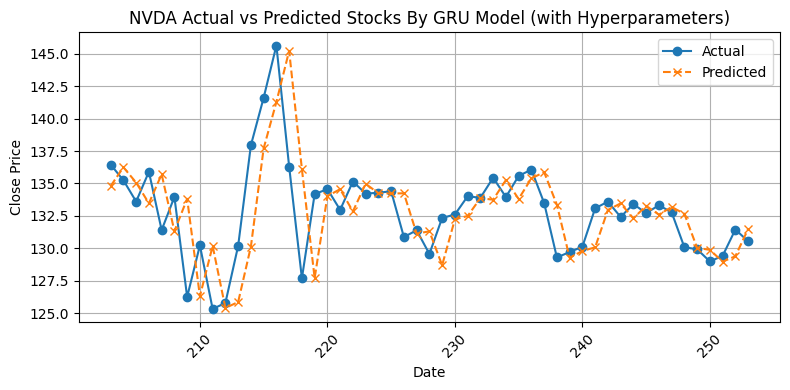

In [218]:
# Recover test dates
dates = stock_nvda_s.index[window_size:][split_idx:]  

plt.figure(figsize=(8,4))
plt.plot(dates, y_true, label='Actual', marker='o')
plt.plot(dates, y_pred, label='Predicted', marker='x', linestyle='--')
plt.title('NVDA Actual vs Predicted Stocks By GRU Model (with Hyperparameters)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Forecast 1, 3 and day 7 

In [220]:
# start from the last window of full data
last_seq = scaled[-window_size:].copy()
future_preds = []


In [221]:
# iteratively predict the next 7 days
for _ in range(7):
    scaled_pred = best_model.predict(last_seq.reshape(1, window_size, 2))[0,0]
    future_preds.append(scaled_pred)
    # Append [predicted_close, last_known_sentiment] and roll the window
    last_sent = last_seq[-1,1]
    new_row = np.array([scaled_pred, last_sent])
    last_seq = np.vstack([last_seq[1:], new_row])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [222]:
#Invert scale to prices
future_full = np.hstack([np.array(future_preds).reshape(-1,1), np.zeros((7,1))])
future_prices = scaler.inverse_transform(future_full)[:,0]


In [223]:
# Print day-1, day-3, day-7
print(f"1-day ahead by GRU: ${future_prices[0]:.2f}")
print(f"3-day ahead by GRU: ${future_prices[2]:.2f}")
print(f"7-day ahead by GRU: ${future_prices[6]:.2f}")


1-day ahead by GRU: $130.23
3-day ahead by GRU: $129.63
7-day ahead by GRU: $128.51


#### Plot days 1, 3 and 7 ahead

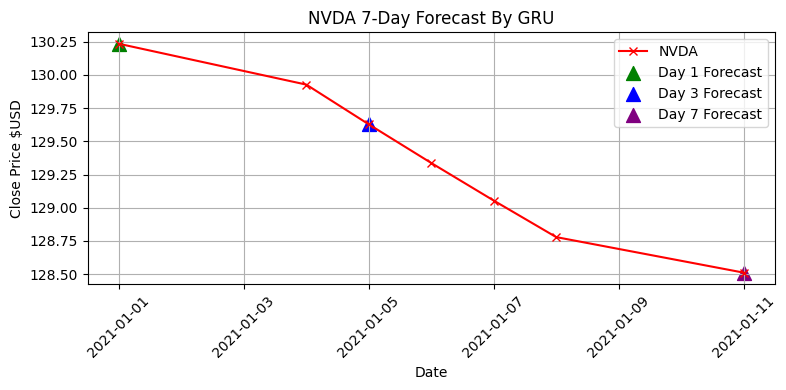

In [224]:
plt.figure(figsize=(8,4))
plt.plot(future_dates, future_prices, label='NVDA', marker='x', color='red')

# Highlight Day 1, 3, and 7 
plt.scatter(future_dates[0], future_prices[0], color='green', label='Day 1 Forecast', s=100, marker='^')
plt.scatter(future_dates[2], future_prices[2], color='blue', label='Day 3 Forecast', s=100, marker='^')
plt.scatter(future_dates[6], future_prices[6], color='purple', label='Day 7 Forecast', s=100, marker='^')

plt.title('NVDA 7-Day Forecast By GRU')
plt.xlabel('Date')
plt.ylabel('Close Price $USD')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('nvda_forecast.png')
plt.show()

## TSLA Forecast with Facebook Prophet

### Load TSLA Stock prices

In [225]:
# Load stock prices
stock = pd.read_csv('TSLA.csv', parse_dates=['Date'])
stock_tsla = stock[['Date', 'Close']]

In [129]:
stock_tsla.head(5)

,Date,Close
0,2019-12-31,27.888666
1,2020-01-02,28.684000
2,2020-01-03,29.534000
3,2020-01-06,30.102667
4,2020-01-07,31.270666


In [226]:
# Change columns to lowercase
stock_tsla.columns = stock_tsla.columns.str.lower()

In [227]:
stock_tsla.head(5)

,date,close
0,2019-12-31,27.888666
1,2020-01-02,28.684000
2,2020-01-03,29.534000
3,2020-01-06,30.102667
4,2020-01-07,31.270666


### Load TSLA tweets with TextBlob Sentiment Analysis

In [228]:
# load tweets
tweet_tsla = pd.read_csv('sentimental_tsla.csv', parse_dates=['date'], dayfirst=True, on_bad_lines='skip')

In [229]:
tweet_tsla.head(5)

,id,date,ticker,tweet,polarity_score
0,100002,2020-01-01,TSLA,$TSLA Daddy's drinkin' eArly tonight! Here's t...,0.156250
1,100004,2020-01-01,TSLA,"$TSLA happy new year, 2020, everyone🍷🎉🙏",0.468182
2,100005,2020-01-01,TSLA,"\$TSLA haha just a collection of greats...\""\""...",0.500000
3,100006,2020-01-01,TSLA,$TSLA NOBODY: Gas cars driven by humans killed...,-0.200000
4,100019,2020-01-03,TSLA,$TSLA I must rise to a level where winning do...,0.500000


In [230]:
#  aggregate sentiment per day
daily_sentiment_tsla = tweet_tsla.groupby('date').agg({'polarity_score': 'mean'}).reset_index()

In [231]:
daily_sentiment_tsla.head(5)

,date,polarity_score
0,2020-01-01,0.231108
1,2020-01-02,-0.800000
2,2020-01-03,0.325000
3,2020-01-04,-0.050000
4,2020-01-06,0.095833


### Merge TSLA Stock with TSLA tweets

In [71]:
# organize date time starting by day
#stock_amzn['date'] = pd.to_datetime(stock_amzn['date'], dayfirst=True)
#daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'], dayfirst=True)

In [232]:
#Merge stock + sentiment
stock_tsla_s = pd.merge(stock_tsla, daily_sentiment_tsla, on='date', how='left')
stock_tsla_s['polarity_score'] = stock_tsla_s['polarity_score'].fillna(0)  # fill missing sentiment with 0

In [147]:
stock_tsla_s.head(5)

,date,close,polarity_score
0,2019-12-31,27.888666,0.000000
1,2020-01-02,28.684000,-0.800000
2,2020-01-03,29.534000,0.325000
3,2020-01-06,30.102667,0.095833
4,2020-01-07,31.270666,0.141695


### Prepare the Data

In [233]:
# Rename columns as Prophet expects
df = stock_tsla_s.rename(columns={'date': 'ds', 'close': 'y'})

# Add sentiment as regressor
df['polarity_score'] = df['polarity_score'].fillna(0)  # handle missing if any


In [210]:
df.head(5)

,ds,y,polarity_score
0,2019-12-31,27.888666,0.000000
1,2020-01-02,28.684000,-0.800000
2,2020-01-03,29.534000,0.325000
3,2020-01-06,30.102667,0.095833
4,2020-01-07,31.270666,0.141695


### Build Prophet Model

In [234]:
model = Prophet()
model.add_regressor('polarity_score')
model.fit(df)


12:34:10 - cmdstanpy - INFO - Chain [1] start processing
12:34:10 - cmdstanpy - INFO - Chain [1] done processing


### make predictions

In [235]:
# Create future dataframe
future = model.make_future_dataframe(periods=7)  # 7 days ahead
future = future.merge(df[['ds', 'polarity_score']], on='ds', how='left')

# Fill future sentiment with last known value (or your own estimates)
future['polarity_score'].fillna(method='ffill', inplace=True)

# Predict
forecast = model.predict(future)


### Plot Forecast

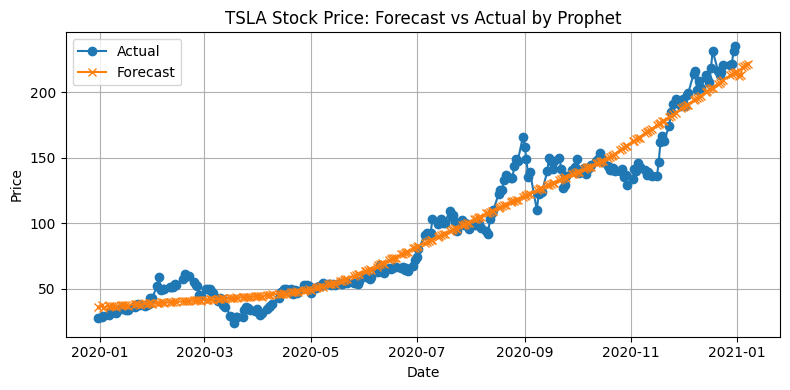

In [236]:
plt.figure(figsize=(8, 4))
plt.plot(df['ds'], df['y'], label='Actual', marker='o')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', marker='x')
plt.title('TSLA Stock Price: Forecast vs Actual by Prophet')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [237]:
# Filter forecast for just the test period
forecast_test = forecast[forecast['ds'].isin(df['ds'])]
# Compute accuracy metrics
rmse = np.sqrt(mean_squared_error(df['y'], forecast_test['yhat']))
mae = mean_absolute_error(df['y'], forecast_test['yhat'])
r2 = r2_score(df['y'], forecast_test['yhat'])

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

RMSE: 12.5775
MAE: 9.4702
R² Score: 0.9500


### Tune Hyperparameters by random search

In [242]:
# Train/validation split
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:]


In [243]:
# funtion for random search

# Regressor name
regressor = 'polarity_score'

def evaluate_prophet(params, train_df, val_df):
    model = Prophet(
        changepoint_prior_scale=params['changepoint_prior_scale'],
        seasonality_prior_scale=params['seasonality_prior_scale'],
        seasonality_mode=params['seasonality_mode']
    )
    model.add_regressor(regressor)

    model.fit(train_df)

    future = model.make_future_dataframe(periods=len(val_df), freq='D')
    # Add regressor values
    future[regressor] = pd.concat([
        train_df[regressor],
        val_df[regressor]
    ]).reset_index(drop=True)

    forecast = model.predict(future)
    forecast_y = forecast[['ds', 'yhat']].iloc[-len(val_df):]['yhat'].values
    true_y = val_df['y'].values

    rmse = np.sqrt(mean_squared_error(true_y, forecast_y))
    return rmse


In [244]:
# Define hyperparameter space
param_space = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}


In [247]:
# Random search
best_rmse = float('inf')
best_params = None
n_iterations = 10

for i in range(n_iterations):
    params = {
        'changepoint_prior_scale': random.choice(param_space['changepoint_prior_scale']),
        'seasonality_prior_scale': random.choice(param_space['seasonality_prior_scale']),
        'seasonality_mode': random.choice(param_space['seasonality_mode']),
    }

    try:
        rmse = evaluate_prophet(params, train_df, val_df)
        print(f"Trial {i+1} | RMSE: {rmse:.4f} | Params: {params}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params
    except Exception as e:
        print(f"Trial {i+1} failed: {e}")

print(f"\Best RMSE: {best_rmse:.4f}")
print(f"Best Params: {best_params}")


12:36:13 - cmdstanpy - INFO - Chain [1] start processing
12:36:13 - cmdstanpy - INFO - Chain [1] done processing
12:36:13 - cmdstanpy - INFO - Chain [1] start processing
12:36:13 - cmdstanpy - INFO - Chain [1] done processing


Trial 1 | RMSE: 30.9888 | Params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}
Trial 2 | RMSE: 54.9009 | Params: {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'multiplicative'}


12:36:13 - cmdstanpy - INFO - Chain [1] start processing
12:36:13 - cmdstanpy - INFO - Chain [1] done processing
12:36:13 - cmdstanpy - INFO - Chain [1] start processing
12:36:14 - cmdstanpy - INFO - Chain [1] done processing


Trial 3 | RMSE: 36.0222 | Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}
Trial 4 | RMSE: 42.9488 | Params: {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}


12:36:14 - cmdstanpy - INFO - Chain [1] start processing
12:36:14 - cmdstanpy - INFO - Chain [1] done processing
12:36:14 - cmdstanpy - INFO - Chain [1] start processing
12:36:14 - cmdstanpy - INFO - Chain [1] done processing


...

Trial 7 | RMSE: 30.9888 | Params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}


12:36:14 - cmdstanpy - INFO - Chain [1] done processing
12:36:15 - cmdstanpy - INFO - Chain [1] start processing
12:36:15 - cmdstanpy - INFO - Chain [1] done processing


Trial 8 | RMSE: 43.0358 | Params: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 0.01, 'seasonality_mode': 'multiplicative'}


12:36:15 - cmdstanpy - INFO - Chain [1] start processing
12:36:15 - cmdstanpy - INFO - Chain [1] done processing


Trial 9 | RMSE: 37.5224 | Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.01, 'seasonality_mode': 'additive'}
Trial 10 | RMSE: 42.9488 | Params: {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}
\Best RMSE: 30.9888
Best Params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}


#### Model with best parameters

In [248]:
p_best_model = Prophet(
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=1.0,
    seasonality_mode='additive'
)
p_best_model.add_regressor('polarity_score')
p_best_model.fit(df)  


12:36:24 - cmdstanpy - INFO - Chain [1] start processing
12:36:24 - cmdstanpy - INFO - Chain [1] done processing


make predictions

In [249]:
# Create future dataframe
future = p_best_model.make_future_dataframe(periods=7)  # 7 days ahead
future = future.merge(df[['ds', 'polarity_score']], on='ds', how='left')

# Fill future sentiment with last known value (or your own estimates)
future['polarity_score'].fillna(method='ffill', inplace=True)

# Predict
forecast = p_best_model.predict(future)


#### Accuracy by Hyperparameters

In [250]:
# Filter forecast for just the test period
forecast_test = forecast[forecast['ds'].isin(df['ds'])]
# Compute accuracy metrics
rmse = np.sqrt(mean_squared_error(df['y'], forecast_test['yhat']))
mae = mean_absolute_error(df['y'], forecast_test['yhat'])
r2 = r2_score(df['y'], forecast_test['yhat'])

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

RMSE: 9.8495
MAE: 7.4160
R² Score: 0.9694


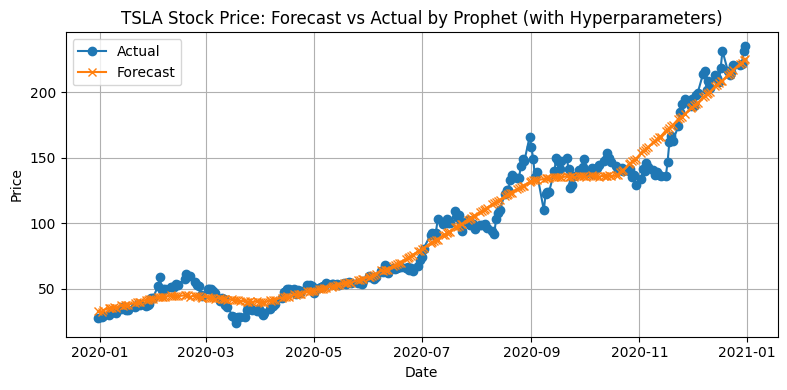

In [251]:
plt.figure(figsize=(8, 4))
plt.plot(df['ds'], df['y'], label='Actual', marker='o')
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Forecast', marker='x')
plt.title('TSLA Stock Price: Forecast vs Actual by Prophet (with Hyperparameters)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Forecasting day 1, 3 and 7 ahead

In [252]:
# Get only the new forecasted days
forecasted_days = forecast.tail(7)

# Get day 1, 3, and 7 forecasts
pred_day1 = forecasted_days.iloc[0][['ds', 'yhat']]
pred_day3 = forecasted_days.iloc[2][['ds', 'yhat']]
pred_day7 = forecasted_days.iloc[6][['ds', 'yhat']]

print("1-Day Forecast:", pred_day1)
print("3-Day Forecast:", pred_day3)
print("7-Day Forecast:", pred_day7)


1-Day Forecast: ds      2021-01-01 00:00:00
yhat             226.070247
Name: 254, dtype: object
3-Day Forecast: ds      2021-01-03 00:00:00
yhat              226.42152
Name: 256, dtype: object
7-Day Forecast: ds      2021-01-07 00:00:00
yhat             233.985629
Name: 260, dtype: object


In [230]:
forecasted_days

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,extra_regressors_additive,...,polarity_score,polarity_score_lower,polarity_score_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
254,2021-01-01,225.819228,213.715891,238.116480,225.819228,225.819228,0.251019,0.251019,0.251019,0.010429,...,0.010429,0.010429,0.010429,0.240591,0.240591,0.240591,0.0,0.0,0.0,226.070247
255,2021-01-02,227.038412,211.858773,237.763438,227.038412,227.038412,-1.836073,-1.836073,-1.836073,0.010429,...,0.010429,0.010429,0.010429,-1.846501,-1.846501,-1.846501,0.0,0.0,0.0,225.202339
256,2021-01-03,228.257596,213.380229,239.219008,228.255613,228.257596,-1.836076,-1.836076,-1.836076,0.010429,...,0.010429,0.010429,0.010429,-1.846504,-1.846504,-1.846504,0.0,0.0,0.0,226.421520
257,2021-01-04,229.476780,217.362554,242.399985,229.434997,229.501014,1.096765,1.096765,1.096765,0.010429,...,0.010429,0.010429,0.010429,1.086337,1.086337,1.086337,0.0,0.0,0.0,230.573545
258,2021-01-05,230.695963,219.587823,243.933904,230.592122,230.783303,0.726834,0.726834,0.726834,0.010429,...,0.010429,0.010429,0.010429,0.716405,0.716405,0.716405,0.0,0.0,0.0,231.422797
259,2021-01-06,231.915147,219.707224,245.492596,231.742681,232.083575,0.819232,0.819232,0.819232,0.010429,...,0.010429,0.010429,0.010429,0.808803,0.808803,0.808803,0.0,0.0,0.0,232.734379
260,2021-01-07,233.134331,221.363415,246.631018,232.854556,233.433959,0.851298,0.851298,0.851298,0.010429,...,0.010429,0.010429,0.010429,0.840869,0.840869,0.840869,0.0,0.0,0.0,233.985629


### Plot  tsla 7 days ahead

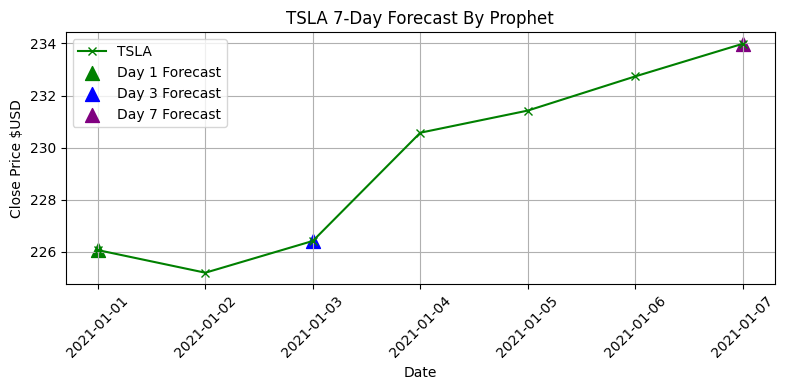

In [253]:
plt.figure(figsize=(8,4))
plt.plot(forecasted_days['ds'], forecasted_days['yhat'], label='TSLA', marker='x', color='green')

# Highlight Day 1, 3, and 7 
plt.scatter(pred_day1['ds'], pred_day1['yhat'], color='green', label='Day 1 Forecast', s=100, marker='^')
plt.scatter(pred_day3['ds'], pred_day3['yhat'], color='blue', label='Day 3 Forecast', s=100, marker='^')
plt.scatter(pred_day7['ds'], pred_day7['yhat'], color='purple', label='Day 7 Forecast', s=100, marker='^')

plt.title('TSLA 7-Day Forecast By Prophet')
plt.xlabel('Date')
plt.ylabel('Close Price $USD')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("tsla_forecast.png")
plt.show()

## Interactive Dashboard

The following Dashboard was designed according to the Tufte's principles.

One.
The representation of numbers, as physically measured on the surface of the graphic itself, should be directly proportional to the numerical quantities measured.

Two.
Clear, detailed, and thorough labeling should be used to defeat graphical distortion and ambiguity. Write out explanations of the data on the graphic itself. Label important events in the data.

Three.
Show data variation, not design variation. 

Four.
In time-series displays of money, deflated and standardized units of monetary measurement are nearly always better than nominal units.

Five.
The number of information-carrying (variable) dimensions depicted should not exceed the number of dimensions in the data. 

Six.
Graphics must not quote data out of context.

In [311]:
forecast_price_future.head()

189    163.047598
190    163.243503
191    164.208055
192    164.002269
193    164.833594
Name: predicted_mean, dtype: float64

In [337]:
# selecting dataframes with forecast
df_aapl = pd.DataFrame({'Date': future_preds['date'], 'Forecast': future_preds['forecast']})
df_amzn = pd.DataFrame({'Date': future_dates, 'Forecast': forecast_price_future.iloc[0:7]})
df_nflx = pd.DataFrame({'Date': future_dates, 'Forecast': preds_price})
df_tsla = pd.DataFrame({'Date': forecasted_days['ds'], 'Forecast':forecasted_days['yhat']})
df_nvda = pd.DataFrame({'Date': future_dates, 'Forecast': future_prices})
 
# Convert 'Date' columns to datetime
for df in [df_aapl, df_amzn, df_nflx, df_tsla, df_nvda]:
    df['Date'] = pd.to_datetime(df['Date'])

# Dictionary of DataFrames
stock_data = {
   'AAPL': df_aapl,
   'AMZN': df_amzn,
   'NFLX': df_nflx,
   'TSLA': df_tsla,
   'NVDA': df_nvda
}


In [338]:
# Initialize the Dash app
app = dash.Dash(__name__)
server = app.server  # For deployment

# Determine the overall date range across all stocks
all_dates = pd.concat([df['Date'] for df in stock_data.values()])
min_date = all_dates.min().date()
max_date = all_dates.max().date()

# Define the layout of the app
app.layout = html.Div([
    html.H1("Stock Forecast Dashboard", style={'textAlign': 'center'}),

    dcc.Dropdown(
        id='stock-dropdown',
        options=[{"label": stock, "value": stock} for stock in stock_data.keys()],
        value='AAPL',
        clearable=False,
        style={'width': '50%', 'margin': 'auto'}
    ),

    dcc.DatePickerRange(
        id='date-picker',
        min_date_allowed=min_date,
        max_date_allowed=max_date,
        start_date=min_date,
        end_date=max_date,
        style={'textAlign': 'center', 'marginTop': 20}
    ),

    dcc.Graph(id='forecast-graph', style={'marginTop': 20})
])


In [339]:
@app.callback(
    Output('forecast-graph', 'figure'),
    Input('stock-dropdown', 'value'),
    Input('date-picker', 'start_date'),
    Input('date-picker', 'end_date')
)
def update_graph(selected_stock, start_date, end_date):
    df = stock_data[selected_stock]
    # Filter data based on selected date range
    mask = (df['Date'] >= pd.to_datetime(start_date)) & (df['Date'] <= pd.to_datetime(end_date))
    filtered_df = df.loc[mask]

    # Create the figure
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=filtered_df['Date'],
        y=filtered_df['Forecast'],
        mode='lines+markers',
        name=selected_stock
    ))
    fig.update_layout(
        title=f'{selected_stock} Forecasted Stock Prices',
        xaxis_title='Date',
        yaxis_title='Price (USD)',
        template='plotly_dark'
    )
    return fig


In [340]:
if __name__ == '__main__':
    app.run(debug=True)


The dash board was developed considering Tufte’s principles, the values using a line chart, aligning with Principle 1 (Proportional representation). As Principle 2 (Clear and detailed labeliling) suggest, the dashboard includes clear labels such as, the title, the timeline, prices, and stock names. The line chart is simple and easy to interpret, avoiding any complex or decorative elements in a 2D plane, in accordance with Principles 3 (Show data variation, not design variation) and 5 (Match variable dimentions to data dimentions). Prices were displayed in USD, as recommended by principle 4 (Use stardardized units). The chat displays the compete forecasted week, ensuring no data is omitted, as emphasized in  Principle 6 (mantain contextual integrity).